In [1]:
import pandas as pd 

In [18]:
df_eng_city = pd.read_csv('./data/England_population_per_city.csv')
df_sp_city = pd.read_csv('./data/Spain_population_per_city.csv')
df_w = pd.read_csv('./data/all_weather_clean.csv')
df_pop_total =pd.read_csv('./data/All_population_monthly.csv')

In [13]:
# Step 1: Fix city names in England population table
df_eng_city['city'] = df_eng_city['city'].replace('Brighton and Hove', 'Brighton')

# Step 2: Exclude Salisbury and Kendal
df_eng_city = df_eng_city[~df_eng_city['city'].isin(['Salisbury', 'Kendal'])]

# Step 3: Add country column to city population tables
df_eng_city['country'] = 'England'
df_sp_city['country'] = 'Spain'

# Step 4: Combine city populations
df_city_pop = pd.concat([df_eng_city, df_sp_city], ignore_index=True)

# Step 5: Merge weather with city population
df_weather_city = df_w.merge(df_city_pop, 
                              left_on=['date', 'station_name'], 
                              right_on=['date', 'city'], 
                              how='inner')

print("After merge:", df_weather_city.shape)
print(df_weather_city[['date', 'station_name', 'tavg', 'prcp', 'tsun', 'population', 'country']].head())

# Step 6: Calculate population-weighted averages per month per country
def weighted_avg(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return None
    return (values[mask] * weights[mask]).sum() / weights[mask].sum()

df_weighted = df_weather_city.groupby(['date', 'country']).apply(
    lambda g: pd.Series({
        'tavg': weighted_avg(g['tavg'], g['population']),
        'prcp': weighted_avg(g['prcp'], g['population']),
        'tsun': weighted_avg(g['tsun'], g['population'])
    })
).reset_index()

df_weighted = df_weighted.round(1)

print(df_weighted.shape)
print(df_weighted.head(10))

After merge: (1380, 11)
      date station_name  tavg  prcp    tsun  population  country
0  2023-07   Sunderland  15.9   NaN  8138.0      279250  England
1  2024-01   Sunderland   5.3   NaN  3962.0      280000  England
2  2024-02   Sunderland   7.3   NaN  3412.0      280125  England
3  2024-03   Sunderland   7.4   NaN  5041.0      280250  England
4  2024-04   Sunderland   8.4   NaN  7932.0      280375  England
(120, 5)
      date  country  tavg  prcp     tsun
0  2021-01  England   3.2  96.3   2290.1
1  2021-01    Spain   7.5  73.9   9277.9
2  2021-02  England   4.9  47.7   3604.3
3  2021-02    Spain  11.9  34.5   8340.4
4  2021-03  England   6.9  38.5   5798.4
5  2021-03    Spain  12.0  15.7  13200.2
6  2021-04  England   6.3  15.5  11765.3
7  2021-04    Spain  14.4  57.8  10749.5
8  2021-05  England  10.3  85.7   8495.9
9  2021-05    Spain  18.5  28.4  16908.0


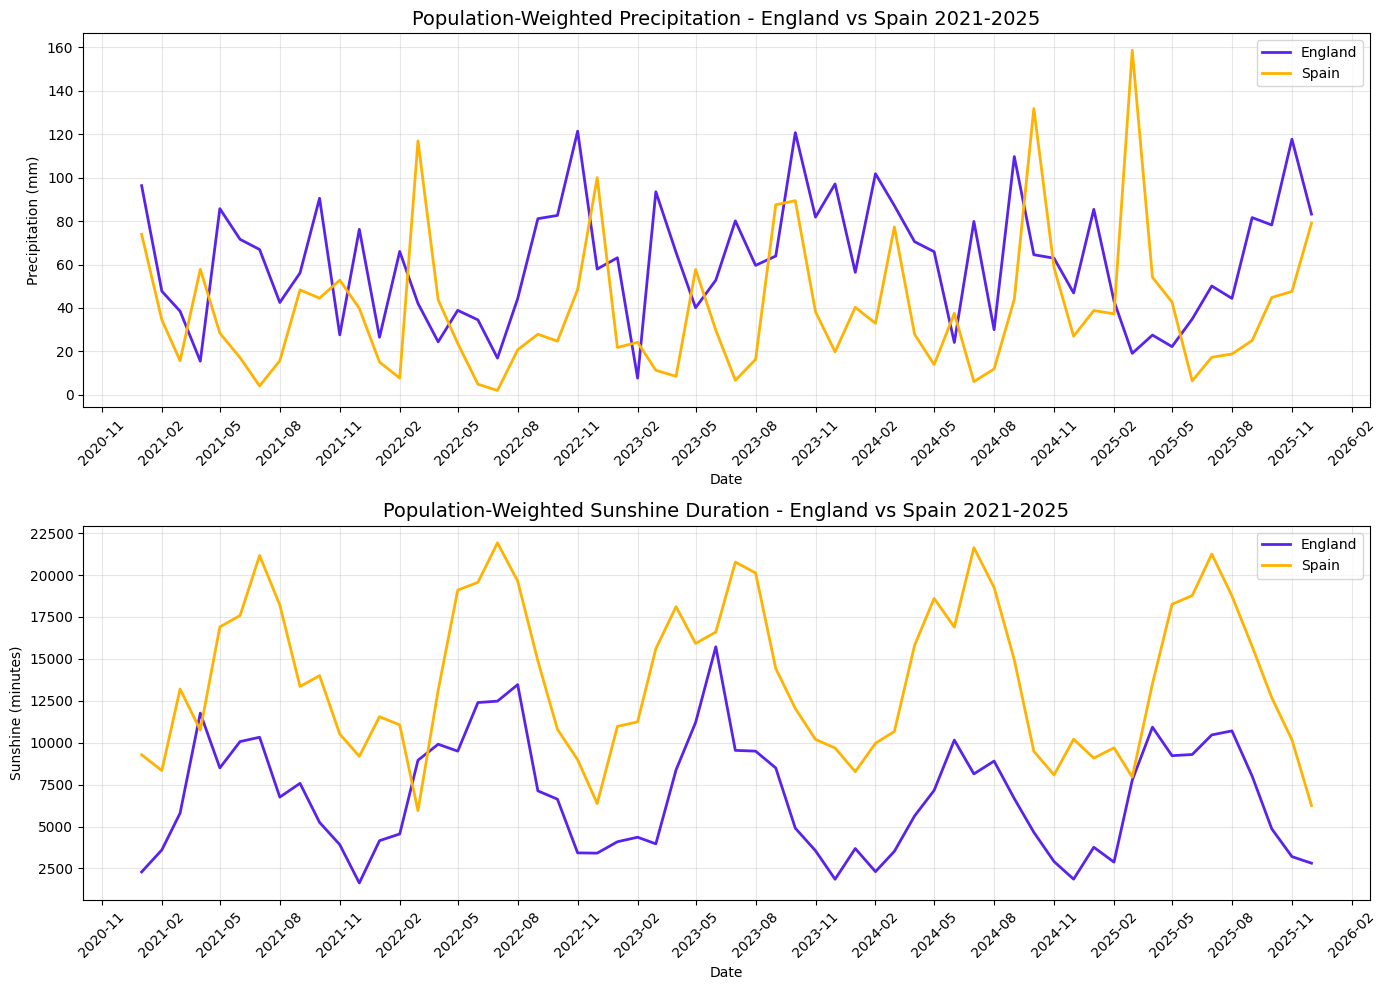

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_weighted['date'] = pd.to_datetime(df_weighted['date'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# PRCP plot
for country, color in zip(['England', 'Spain'], ['#5923ed', '#ffb300']):
    df_c = df_weighted[df_weighted['country'] == country].sort_values('date')
    ax1.plot(df_c['date'], df_c['prcp'], label=country, color=color, linewidth=2)

ax1.set_title('Population-Weighted Precipitation - England vs Spain 2021-2025', fontsize=14)
ax1.set_xlabel('Date')
ax1.set_ylabel('Precipitation (mm)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# TSUN plot
for country, color in zip(['England', 'Spain'], ['#5923ed', '#ffb300']):
    df_c = df_weighted[df_weighted['country'] == country].sort_values('date')
    ax2.plot(df_c['date'], df_c['tsun'], label=country, color=color, linewidth=2)

ax2.set_title('Population-Weighted Sunshine Duration - England vs Spain 2021-2025', fontsize=14)
ax2.set_xlabel('Date')
ax2.set_ylabel('Sunshine (minutes)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

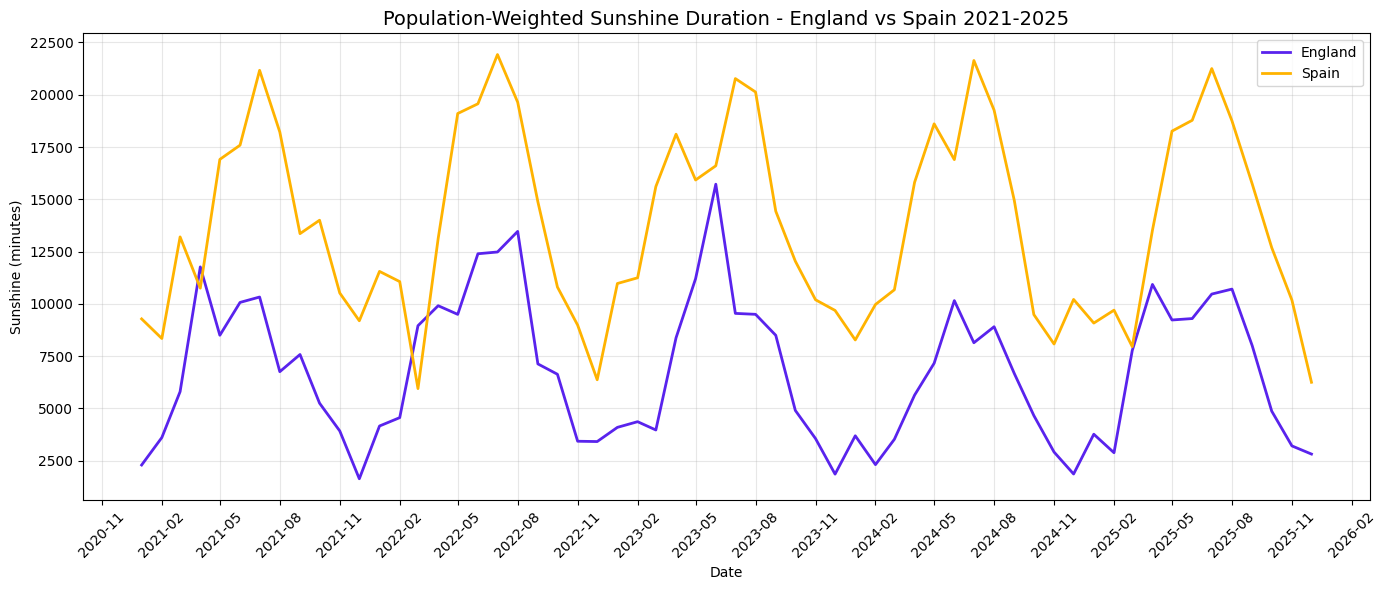

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

df_weighted['date'] = pd.to_datetime(df_weighted['date'])

for country, color in zip(['England', 'Spain'], ['#5923ed', '#ffb300']):
    df_c = df_weighted[df_weighted['country'] == country].sort_values('date')
    ax.plot(df_c['date'], df_c['tsun'], label=country, color=color, linewidth=2)

ax.set_title('Population-Weighted Sunshine Duration - England vs Spain 2021-2025', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Sunshine (minutes)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

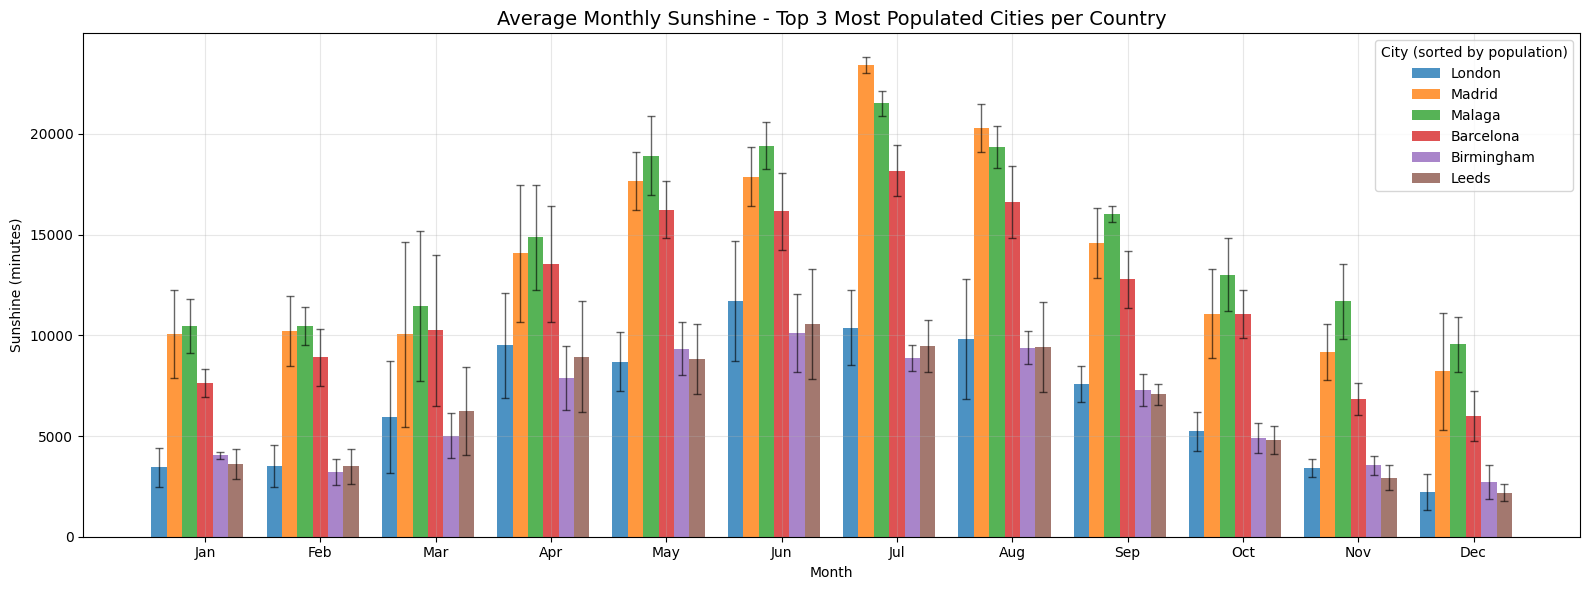

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Get top 3 cities by population for each country
top_england = df_eng_city[df_eng_city['date'] == '2021-01'].nlargest(3, 'population')[['city', 'population']]
top_spain = df_sp_city[df_sp_city['date'] == '2021-01'].nlargest(3, 'population')[['city', 'population']]

# Sort all cities by population descending
all_top = pd.concat([top_england, top_spain]).sort_values('population', ascending=False)
cities = all_top['city'].tolist()

# Get average and std tsun per month per city
df_weather_city['month'] = pd.to_datetime(df_weather_city['date']).dt.month
df_top = df_weather_city[df_weather_city['station_name'].isin(cities)]
df_monthly_avg = df_top.groupby(['month', 'station_name']).agg(
    tsun_mean=('tsun', 'mean'),
    tsun_std=('tsun', 'std')
).reset_index()

# Plot
fig, ax = plt.subplots(figsize=(16, 6))

colors = plt.cm.tab10.colors
width = 0.8 / len(cities)

for i, city in enumerate(cities):
    df_city = df_monthly_avg[df_monthly_avg['station_name'] == city]
    x = df_city['month'] + (i - len(cities)/2) * width
    ax.bar(x, df_city['tsun_mean'], width=width, label=city, color=colors[i], alpha=0.8)
    ax.errorbar(x, df_city['tsun_mean'], yerr=df_city['tsun_std'],
                fmt='none', color='black', capsize=3, linewidth=1, alpha=0.6)

ax.set_title('Average Monthly Sunshine - Top 3 Most Populated Cities per Country', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Sunshine (minutes)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='City (sorted by population)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

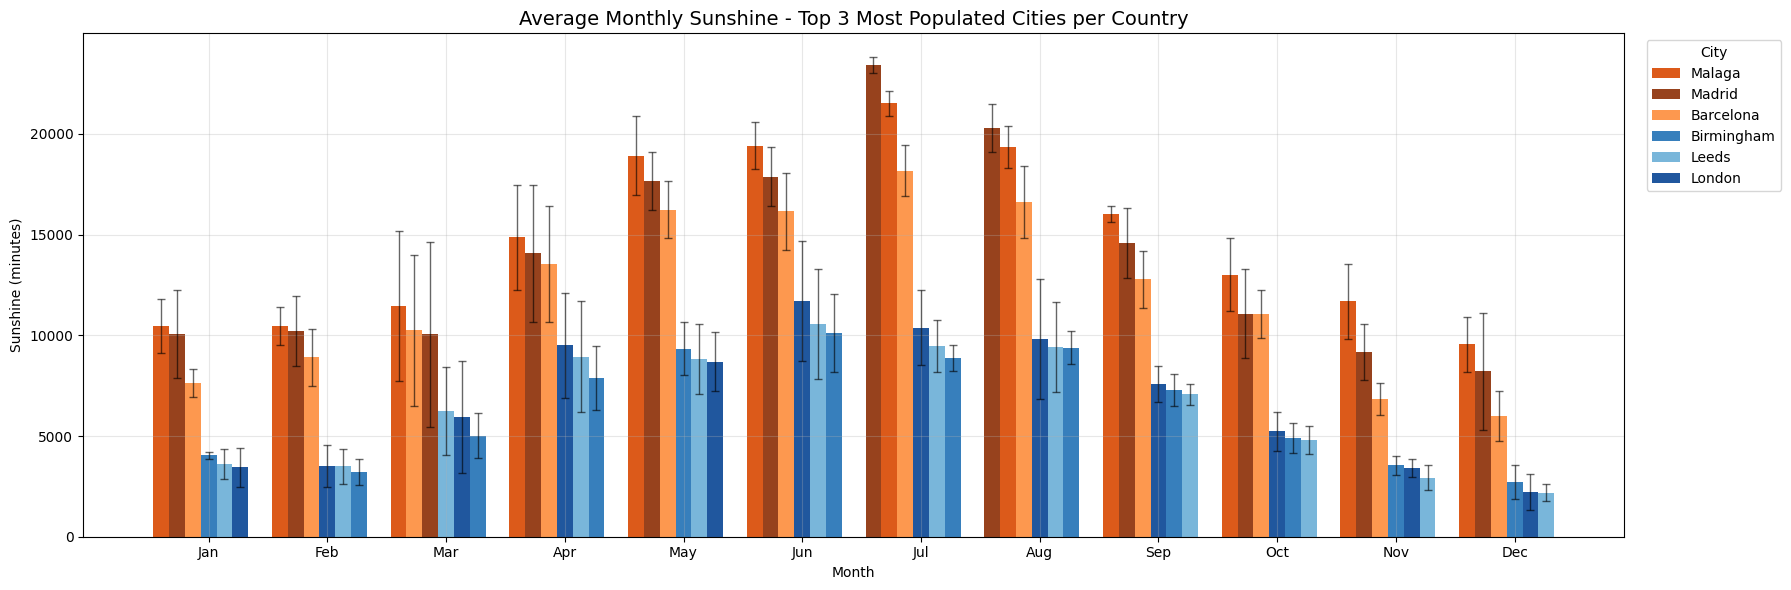

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get top 3 cities by population for each country
top_england = df_eng_city[df_eng_city['date'] == '2021-01'].nlargest(3, 'population')[['city', 'population']]
top_spain = df_sp_city[df_sp_city['date'] == '2021-01'].nlargest(3, 'population')[['city', 'population']]

all_top = pd.concat([top_england, top_spain]).sort_values('population', ascending=False)
cities = all_top['city'].tolist()

england_cities = top_england['city'].tolist()
spain_cities = top_spain['city'].tolist()

# Color shades
blue_shades = ['#084594', '#2171b5', '#6baed6']
orange_shades = ['#8c2d04', '#d94801', '#fd8d3c']

england_colors = {city: blue_shades[i] for i, city in enumerate(
    top_england.sort_values('population', ascending=False)['city'])}
spain_colors = {city: orange_shades[i] for i, city in enumerate(
    top_spain.sort_values('population', ascending=False)['city'])}
city_colors = {**england_colors, **spain_colors}

# Get average and std tsun per month per city
df_weather_city['month'] = pd.to_datetime(df_weather_city['date']).dt.month
df_top = df_weather_city[df_weather_city['station_name'].isin(cities)]
df_monthly_avg = df_top.groupby(['month', 'station_name']).agg(
    tsun_mean=('tsun', 'mean'),
    tsun_std=('tsun', 'std')
).reset_index()

# Plot
fig, ax = plt.subplots(figsize=(18, 6))
width = 0.8 / len(cities)

for month in range(1, 13):
    df_month = df_monthly_avg[df_monthly_avg['month'] == month].sort_values('tsun_mean', ascending=False)
    
    for i, (_, row) in enumerate(df_month.iterrows()):
        city = row['station_name']
        x = month + (i - len(cities)/2) * width
        ax.bar(x, row['tsun_mean'], width=width, 
               label=city if month == 1 else '', 
               color=city_colors[city], alpha=0.9)
        ax.errorbar(x, row['tsun_mean'], yerr=row['tsun_std'],
                    fmt='none', color='black', capsize=3, linewidth=1, alpha=0.6)

ax.set_title('Average Monthly Sunshine - Top 3 Most Populated Cities per Country', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Sunshine (minutes)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='City', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Step 1: Merge weather with Spain city population
spain_cities = ['Bilbao', 'Santiago de Compostela', 'Valencia', 'Barcelona', 
                'Seville', 'Malaga', 'Madrid', 'Zaragoza']

df_w_spain = df_w[df_w['station_name'].isin(spain_cities)].copy()

# Merge with city population
df_w_spain = df_w_spain.merge(df_sp_city, 
                               left_on=['date', 'station_name'], 
                               right_on=['date', 'city'], 
                               how='left')

# Merge with total Spain population
df_w_spain = df_w_spain.merge(df_pop_total[['date', 'population']], 
                               on='date', 
                               how='left',
                               suffixes=('_city', '_total'))

# Step 2: Calculate weight
df_w_spain['weight'] = df_w_spain['population_city'] / df_w_spain['population_total']

# Step 3: Calculate weighted values
df_w_spain['tavg_w'] = df_w_spain['tavg'] * df_w_spain['weight']
df_w_spain['prcp_w'] = df_w_spain['prcp'] * df_w_spain['weight']
df_w_spain['tsun_w'] = df_w_spain['tsun'] * df_w_spain['weight']

# Step 4: Group by date and sum weighted values
df_spain_weighted = df_w_spain.groupby('date').agg(
    tavg=('tavg_w', 'sum'),
    prcp=('prcp_w', 'sum'),
    tsun=('tsun_w', 'sum')
).round(1).reset_index()

df_spain_weighted['country'] = 'Spain'

print(df_spain_weighted.head(10))

      date  tavg  prcp    tsun country
0  2021-01   2.7  26.5  3323.0   Spain
1  2021-02   4.2  12.3  2970.0   Spain
2  2021-03   4.3   5.6  4673.3   Spain
3  2021-04   5.1  20.3  3783.5   Spain
4  2021-05   6.5  10.0  5915.3   Spain
5  2021-06   8.0   5.9  6116.2   Spain
6  2021-07   8.8   1.4  7316.7   Spain
7  2021-08   9.0   5.4  6255.8   Spain
8  2021-09   7.7  16.5  4557.0   Spain
9  2021-10   6.1  15.1  4745.1   Spain


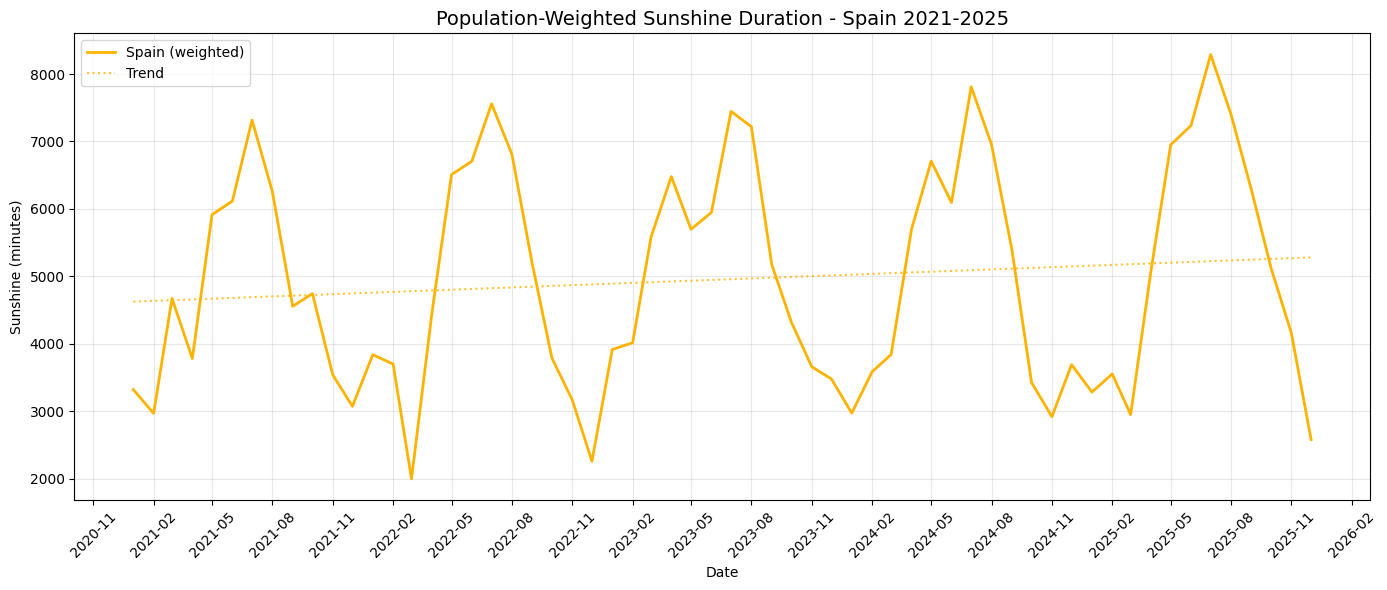

In [21]:
from matplotlib.dates import date2num
fig, ax = plt.subplots(figsize=(14, 6))

df_spain_weighted['date'] = pd.to_datetime(df_spain_weighted['date'])

ax.plot(df_spain_weighted['date'], df_spain_weighted['tsun'], 
        color='#ffb300', linewidth=2, label='Spain (weighted)')

# Trend line
x_num = date2num(df_spain_weighted['date'].values)
z = np.polyfit(x_num, df_spain_weighted['tsun'], 1)
p = np.poly1d(z)
ax.plot(df_spain_weighted['date'], p(x_num), 
        color='#ffb300', linestyle=':', linewidth=1.5, alpha=0.8, label='Trend')

ax.set_title('Population-Weighted Sunshine Duration - Spain 2021-2025', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Sunshine (minutes)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()